<a href="https://colab.research.google.com/github/godmsqls/Advanced-Major-Practice/blob/main/AMP_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 지난 시간 복습
흑백 이미지
- 하나의 픽셀은 하나의 숫자 (밝기 값) : 0~ 255
- 값이 작을수록 어두움

컬러 이미지
- 하나의 픽셀은 세 개의 숫자 (B, G, R)

해상도 = 가로 픽셀 수 × 세로 픽셀 수



## 히스토그램

이미지에서 특정 밝기값(픽셀 값)이 얼마나 많이 나타나는지를 시각적으로 표현한 그래프
- 가로축 : 픽셀 값 (0 ~ 255)
- 세로축 : 각 픽셀 값의 픽셀 개수 (빈도)
- 막대 그래프 : 그래프의 형태로 이미지의 밝기 분포 특성 파악

### → 히스토그램을 통해 알 수 있는 것

- 이미지가 전반적으로 어두운지, 밝은지
- 명암 대비(동적 범위)의 정도
- 어떤 밝기 영역에 픽셀이 집중되어 있는지
- 과노출/과소노출 여부 확인

## 밝기 조절 실습 코드

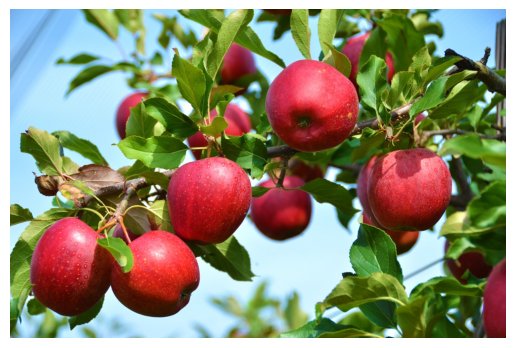

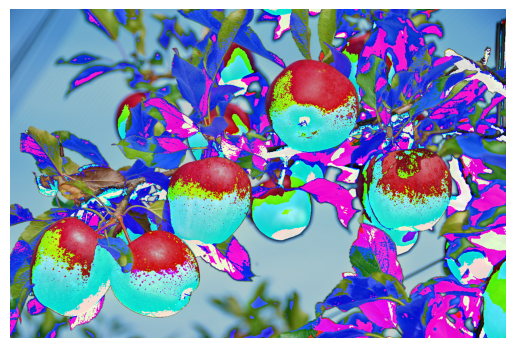

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 원본 이미지
img = cv2.imread('apples.jpg')
# 컬러 이미지를 RGB로 변환
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 원본 이미지 출력
plt.imshow(img)
plt.axis('off')
plt.show()

# 밝기 증가 상수
c = 50

result = img - c
# 0~255 범위로 제한
result = np.clip(result, 0, 255).astype(np.uint8)

# 밝기 수정한 이미지 출력
plt.imshow(result)
plt.axis('off')
plt.show()

## 대비 조절 실습 코드

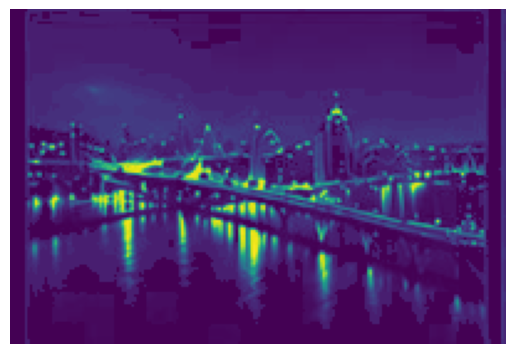

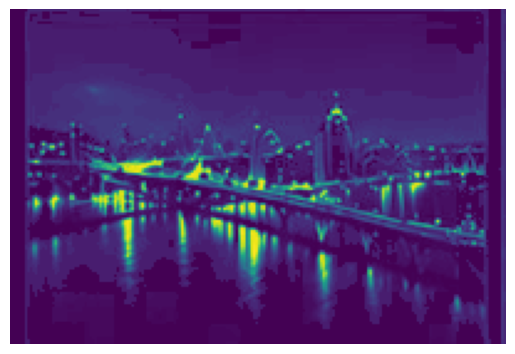

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 원본 이미지
img = cv2.imread('city_night.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(img)
plt.axis('off')
plt.show()

# c = 50
# result = img + c

alpha = 0.5
result = alpha * (img.astype(np.float32) - 128) + 128
result = np.clip(result, 0, 255).astype(np.uint8)

# cv2.imwrite('city_night_minus50.jpg', result)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.imshow(result)
plt.axis('off')
plt.show()

## 밝기, 대비 동시 조절 실습 코드

이 부분 중요!!!!!! 히스토그램 확인도 해보기

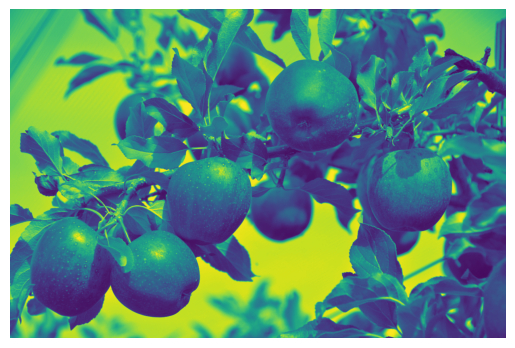

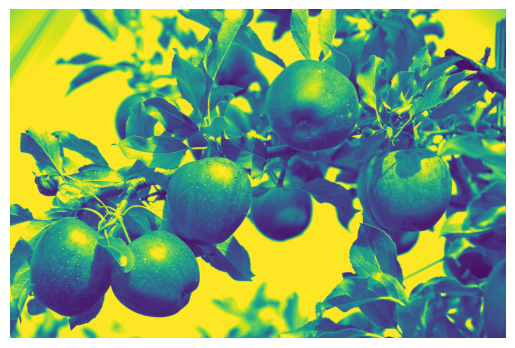

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('apples.jpg', cv2.IMREAD_GRAYSCALE)
alpha = 1.2
c = 20

result = cv2.convertScaleAbs(img, alpha=alpha, beta=c)

plt.imshow(img)
plt.axis('off')
plt.show()

plt.imshow(result)
plt.axis('off')
plt.show()

## OpenCV로 직접 구현해보기

/tmp/ipykernel_1032/1584405886.py:39: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1032/1584405886.py:39: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1032/1584405886.py:39: UserWarning: Glyph 48157 (\N{HANGUL SYLLABLE BALG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1032/1584405886.py:39: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1032/1584405886.py:39: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1032/1584405886.py:39: UserWarning: Glyph 46177 (\N{HANGUL SYLLABLE DUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1032/1584405886.py:39: UserWarning: Glyph 45824 (

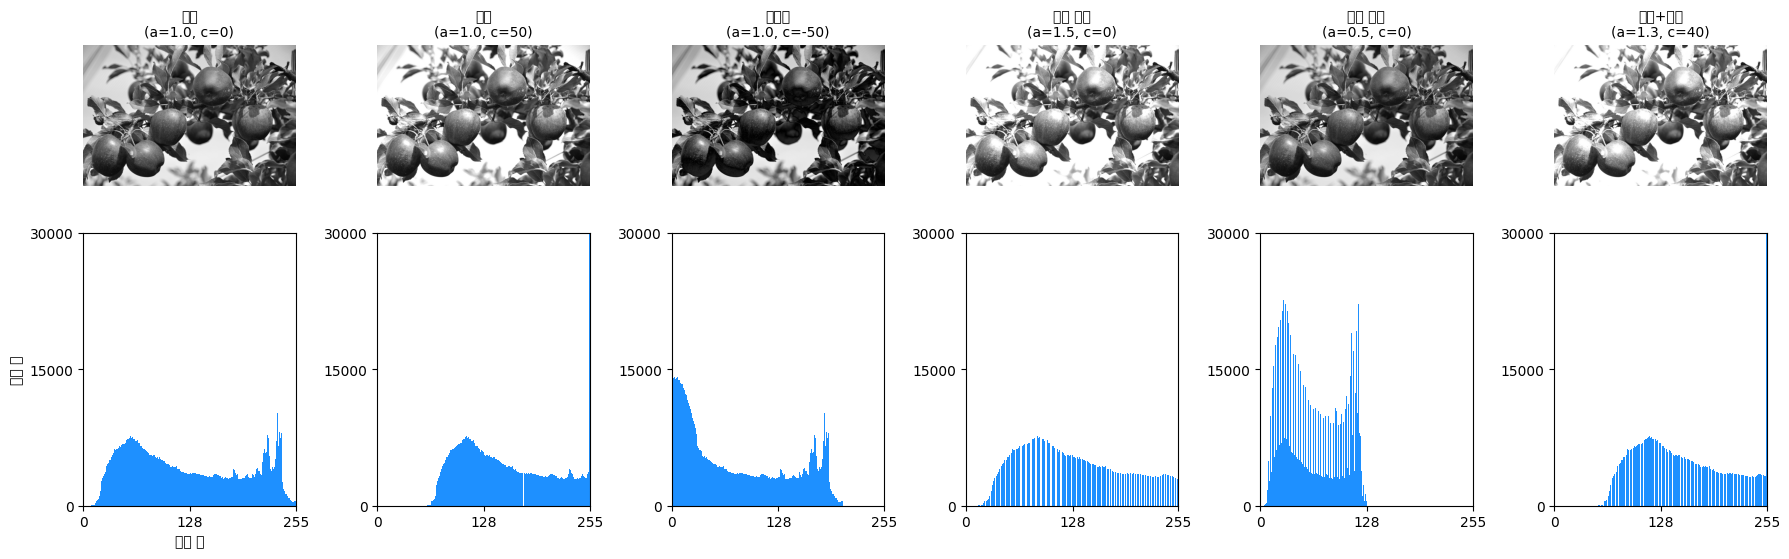

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 이미지 읽기
img = cv2.imread('apples.jpg', cv2.IMREAD_GRAYSCALE)

# 2. 함수 징의
def adjust_brightness_contrast(img, alpha=1.0, beta=0):
  return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

# 3. 디앙한 값 조합
params = [
('원본', 1.0, 0),
('밝게', 1.0, 50),
('어둡게', 1.0, -50),
('대비 중가', 1.5, 0),
('대비 감소', 0.5, 0),
('밝기+대비', 1.3, 40)
]

results = []
for name, alpha, beta in params:
  out = adjust_brightness_contrast(img, alpha, beta)
  results.append((name, alpha, beta, out))

# 4. 결과 시각화
fig, axes = plt.subplots(2, len(results), figsize=(18, 6))
for i, (name, alpha, beta, out) in enumerate(results):
  axes[0, i].imshow(out, cmap='gray')
  axes[0, i].set_title(f"{name}\n(a={alpha}, c={beta})", fontsize=10)
  axes[0, i].axis('off')
  axes[1, i].hist(out.ravel(), bins=256, range=(0,255), color='dodgerblue')
  axes[1, i].set_xlim(0,255); axes[1, i].set_ylim(0,30000)
  axes[1, i].set_xticks([0,128,255]); axes[1, i].set_yticks([0,15000,30000])
  if i == 0:
    axes[1,i].set_ylabel('픽셀 수')
    axes[1, i].set_xlabel('픽셀 값')
plt.tight_layout(); plt.show()